In [ ]:
import pandas as pd
!pip install sentencepiece

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from torch.optim import AdamW          # fixed: transformers' AdamW is deprecated
import torch
from torch.utils.data import DataLoader, TensorDataset
from transformers import (
    BertTokenizer, BertForSequenceClassification,
    XLMRobertaTokenizer, XLMRobertaForSequenceClassification,
)

# Load dataset
df = pd.read_csv('train_data_mal_fake_detect.csv')

# Stratified split preserves class proportions; falls back to random if any
# class is too small (sklearn requires >= 2 samples per class to stratify).
try:
    train_df, val_df = train_test_split(df, test_size=0.2, random_state=42,
                                        stratify=df["Label"])
except ValueError as e:
    print(f"Warning: stratified split failed ({e}), falling back to random split")
    train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

# Label Encoding — fit only on train, transform val with the same mapping
le = LabelEncoder()
train_df = train_df.copy()
val_df   = val_df.copy()
train_df['Label'] = le.fit_transform(train_df['Label'])
val_df['Label']   = le.transform(val_df['Label'])

num_classes = 5
# Fixed: was 1, which trained the model on only 5 total samples (1 per class).
# 200 per class with replacement oversampling gives a properly balanced batch.
sample_size = 200

dft  = train_df
dft4 = pd.DataFrame(columns=['News', 'Label'])
for i in range(num_classes):
    dft2 = dft[dft['Label'] == i]
    if len(dft2) == 0:
        continue
    replace = len(dft2) < sample_size   # oversample minority classes
    dft3 = dft2.sample(sample_size, replace=replace, random_state=42)
    dft4 = pd.concat([dft4, dft3])

train_ds1 = dft4

# mBERT tokenizer — multilingual, works for Malayalam.
# bert-base-uncased was removed: it is English-only.
tokenizer = BertTokenizer.from_pretrained('bert-base-multilingual-uncased')

# Model must be instantiated before use
model = BertForSequenceClassification.from_pretrained(
    'bert-base-multilingual-uncased', num_labels=num_classes
)

train_encodings = tokenizer(
    train_ds1['News'].tolist(), truncation=True, padding=True,
    max_length=256, return_tensors='pt'
)
train_labels = torch.tensor(train_ds1['Label'].tolist())

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
train_encodings = {k: v.to(device) for k, v in train_encodings.items()}
train_labels    = train_labels.to(device)

optimizer = AdamW(model.parameters(), lr=1e-5)

for epoch in range(3):
    model.train()
    optimizer.zero_grad()
    outputs = model(**train_encodings, labels=train_labels)
    loss = outputs.loss
    loss.backward()
    optimizer.step()
    print(f"Epoch {epoch + 1}/3 — Loss: {loss.item():.4f}")

In [ ]:
model.eval()

val_texts  = [str(t) for t in val_df['News'].tolist()]
val_labels = torch.tensor(val_df['Label'].tolist())

val_encodings = tokenizer(val_texts, truncation=True, padding=True,
                          max_length=256, return_tensors='pt')

# Fixed: was hardcoded to torch.device('cuda'), which crashes on CPU-only machines.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
val_encodings = {k: v.to(device) for k, v in val_encodings.items()}
val_labels    = val_labels.to(device)

with torch.no_grad():
    outputs = model(**val_encodings)
    _, predicted = torch.max(outputs.logits, 1)

val_preds = le.inverse_transform(predicted.cpu().numpy())
val_true  = le.inverse_transform(val_labels.cpu().numpy())

print(classification_report(val_true, val_preds, zero_division=1))

unique_labels = le.classes_
cm = confusion_matrix(val_true, val_preds, labels=unique_labels)
ConfusionMatrixDisplay(cm, display_labels=unique_labels).plot()

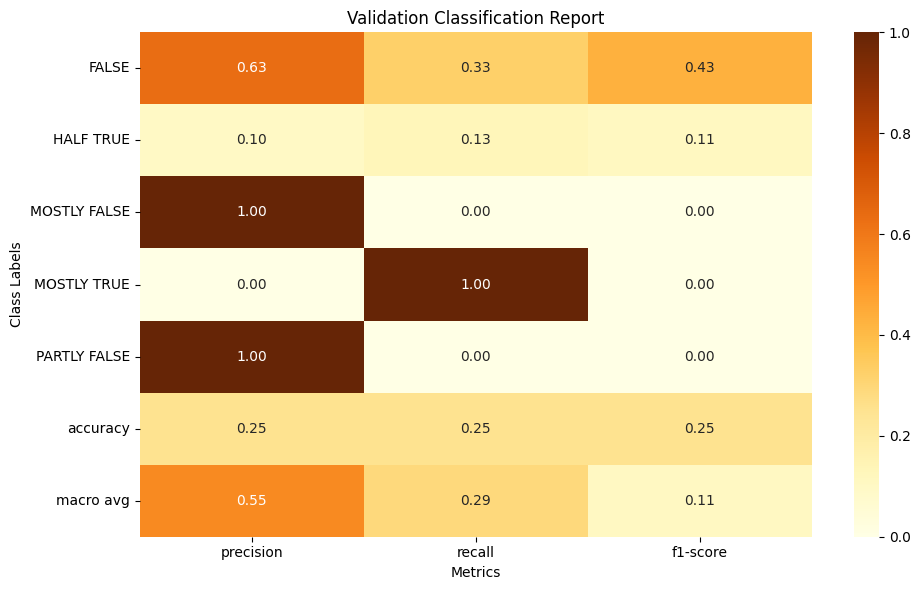

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix

# Assuming you have the true class labels in val_true and predictions in val_preds
report = classification_report(val_true, val_preds, zero_division=1, output_dict=True)

# Convert the report dictionary to a DataFrame for easier visualization
report_df = pd.DataFrame(report).transpose()

# Plot the precision, recall, and F1-score as a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(report_df.iloc[:-1, :-1], annot=True, cmap='YlOrBr', fmt='.2f', cbar=True)

# Customize the plot if needed
plt.title('Validation Classification Report')
plt.xlabel('Metrics')
plt.ylabel('Class Labels')
plt.tight_layout()
plt.show()


In [ ]:
test_df         = pd.read_csv("test-data.csv")
test_df['News'] = test_df['News'].astype(str)
texts           = test_df['News'].tolist()

# Batch inference to avoid OOM — tokenising all 1000+ rows at once allocates
# a single large tensor; batching keeps peak memory bounded.
BATCH_SIZE = 32
all_preds  = []

model.eval()
with torch.no_grad():
    for i in range(0, len(texts), BATCH_SIZE):
        batch     = texts[i : i + BATCH_SIZE]
        encodings = tokenizer(batch, truncation=True, padding=True,
                              max_length=256, return_tensors='pt')
        encodings = {k: v.to(device) for k, v in encodings.items()}
        outputs   = model(**encodings)
        _, preds  = torch.max(outputs.logits, 1)
        all_preds.extend(preds.cpu().numpy())

predicted_labels     = le.inverse_transform(all_preds)
test_df['predicted'] = predicted_labels
test_df.to_csv('XLM-R.csv', index=False)